In [11]:
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
import mmtrack.mm_cell_segmentation as mm3seg
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from mmtrack import pre_process_mm
from mmtrack import plot_cells
import warnings
import networkx as nx
import tifffile
from skimage.filters import threshold_otsu
import skimage.segmentation as segmentation
from skimage import segmentation, morphology, measure, filters
import scipy.ndimage as ndi
from skimage.filters import threshold_local
import json
import pandas as pd

ImportError: cannot import name 'threshold_ots' from 'skimage.filters' (/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/skimage/filters/__init__.py)

In [2]:
def get_tiff_frame_count(file_path):
	"""Reads a TIFF file and returns the index of the last time frame (T - 1)."""
	try:
		# 1. Read the image data into a NumPy array
		img_stack = tifffile.imread(file_path)

		# 2. Get the shape of the array
		shape = img_stack.shape

		# 3. Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1, which is shape[0] - 1
			last_frame_index = shape[0] - 1
			return last_frame_index
		else:
			# Handle case where the file might be a single 2D image (T=1, last index 0)
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0
	
def overlap(bbox1, bbox2):
    """Checks if two bounding boxes overlap."""
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])
    return x1 < x2 and y1 < y2


def segment_image(image,
				  OTSU_threshold=1.5,
				  first_opening=5,
				  distance_threshold=3,
				  second_opening_size=1,
				  min_cell_area=200,
				  max_cell_area=700,
				  small_merge_area_threshold=50,
				  min_axis_ratio=0.04,
				  first_opening_morph=None,
				  second_opening_morph=None):
	"""Segments an image with size and shape filtering, and improved structure."""
	
	scale = np.median(image) / np.mean(image)
	image = image.astype(np.float32)
	image = (image - np.percentile(image, 1)) / (
		np.percentile(image, 99) - np.percentile(image, 1)
	)
	image = np.clip(image, 0, 1)

	# 1. Thresholding and Initial Morphological Operations
	try:
		with warnings.catch_warnings():
			warnings.simplefilter("ignore")
			thresh = filters.threshold_otsu(image)
		thresholded = image > OTSU_threshold * thresh
		
		if first_opening_morph == 1:
			# Use diagonal opening
			diagonal_footprint = np.zeros((first_opening, first_opening))
			np.fill_diagonal(diagonal_footprint, 1)
			morph = morphology.binary_opening(thresholded, diagonal_footprint)
		else:
			# Use disk opening (default when first_opening_morph is 0 or None)
			morph = morphology.binary_opening(thresholded, morphology.disk(first_opening))

		if np.amax(morph) == 0:
			return np.zeros_like(image)

		distance = ndi.distance_transform_edt(morph)
		distance_thresh = distance >= distance_threshold

		#if using spherical opening
		if second_opening_morph == 1:
			# Use diagonal opening
			diagonal_footprint_two = np.zeros((second_opening_size, second_opening_size))
			np.fill_diagonal(diagonal_footprint_two, 1)
			distance_opened = morphology.binary_opening(distance_thresh, diagonal_footprint_two)
		else:
			# Use disk opening (default when second_opening_morph is 0 or None)
			distance_opened = morphology.binary_opening(distance_thresh, morphology.disk(second_opening_size))
			
		labeled, num_labels = morphology.label(distance_opened, connectivity=1, return_num=True)
		if num_labels == 0:
			return np.zeros_like(image)

		markers = morphology.label(labeled, connectivity=1)
		markers = markers.astype(np.int32)
		if np.amax(markers) == 0:
			return np.zeros_like(image)

	except Exception as e:
		print(f"Error in initial processing: {e}")
		return np.zeros_like(image)
		
	
	# 2. Watershed Segmentation
	thresholded_watershed = thresholded
	image_float = image.astype(np.float64)
	try:
		markers[thresholded_watershed == 0] = -1
		with warnings.catch_warnings():
			warnings.simplefilter("ignore")
			labeled_image = segmentation.random_walker(-1 * image_float, markers)
		labeled_image[labeled_image == -1] = 0
	except Exception as e:
		print(f"Error in watershed segmentation: {e}")
		return np.zeros_like(image)

	# 3. Bounding Box Merging (Small Regions)
	regions = measure.regionprops(labeled_image)
	if regions:
		bboxes = np.array([region.bbox for region in regions])
		areas = np.array([region.area for region in regions])
		graph = nx.Graph()

		for i, bbox1 in enumerate(bboxes):
			for j, bbox2 in enumerate(bboxes):
				if i != j and overlap(bbox1, bbox2) and areas[i] < small_merge_area_threshold and areas[j] < small_merge_area_threshold:
					graph.add_edge(regions[i].label, regions[j].label)

		for component in nx.connected_components(graph):
			if len(component) > 1:
				merged_mask = np.isin(labeled_image, list(component))
				new_label = np.max(labeled_image) + 1
				labeled_image[merged_mask] = new_label
				for label in component:
					labeled_image[labeled_image == label] = 0

		labeled_image, _ = morphology.label(labeled_image, connectivity=1, return_num=True)

	# 4. Shape Filtering (Axis Ratio)
	filtered_labeled_image = np.zeros_like(labeled_image)
	regions = measure.regionprops(labeled_image)

	for region in regions:
		if region.axis_major_length > 0:
			axis_ratio = region.axis_minor_length / region.axis_major_length
			if (axis_ratio > min_axis_ratio) | (region.axis_minor_length > 3.5):
				filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label

	labeled_image = filtered_labeled_image

	# 5. Size Filtering (Area)
	if min_cell_area is not None or max_cell_area is not None:
		filtered_labeled_image = np.zeros_like(labeled_image)
		regions = measure.regionprops(labeled_image)
		for region in regions:
			area = region.area
			if (min_cell_area is None or area >= min_cell_area) and (max_cell_area is None or area <= max_cell_area):
				filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label
		labeled_image = filtered_labeled_image

	return labeled_image

In [3]:
# new function definition

def segment_chnl_stack(path_to_phase_channel_stack,
					   output_path,
					   OTSU_threshold=1.5,
					   first_opening=5,
					   distance_threshold=3,
					   second_opening_size=1,
					   min_cell_area=200,
					   max_cell_area=700,
					   small_merge_area_threshold=50,
					   seg_params=None,
					   first_opening_morph=None,
					   second_opening_morph=None):
	"""
	For a given fov and peak (channel), do segmentation for all images in the
	subtracted .tif stack.
	Adapted from napari-mm3
	"""

	path_to_mm3_seg = os.path.join(output_path, 'mm3_segmentation')
	os.makedirs(path_to_mm3_seg, exist_ok=True)

	save_to_path = os.path.dirname(path_to_phase_channel_stack)
	filename = os.path.basename(path_to_phase_channel_stack)
	phase_stack = tifffile.imread(path_to_phase_channel_stack)

	min_axis_ratio = 0.04

	# image by image for debug
	segmented_imgs = []
	for time in range(phase_stack.shape[0]):
		if seg_params is not None:
			# Find which row's range contains the current time
			for idx, row in seg_params.iterrows():
				if time in row['range']:
					unstacked_seg_image = segment_image(phase_stack[time, :, :],
														row['OTSU_threshold'],
														row['first_opening'],
														row['distance_threshold'],
														row['second_opening_size'],
														row['min_cell_area'],
														row['max_cell_area'],
														row['small_merge_area_threshold'],
														row['min_axis_ratio'],
														row['first_opening_morph'],
														row['second_opening_morph'])

					unstacked_seg_image = unstacked_seg_image.astype("uint8")
					unstacked_seg_filename = f'mask_t_{time:03d}_{filename}'
					unstacked_path = os.path.join(path_to_mm3_seg, unstacked_seg_filename)
					tifffile.imwrite(unstacked_path, unstacked_seg_image)
					segmented_imgs.append(unstacked_seg_image)
					break  # Found the matching range, exit inner loop
		else:
			unstacked_seg_image = segment_image(phase_stack[time, :, :],
												OTSU_threshold,
												first_opening,
												distance_threshold,
												second_opening_size,
												min_cell_area,
												max_cell_area,
												small_merge_area_threshold,
												min_axis_ratio,
												first_opening_morph,
												second_opening_morph)
			unstacked_seg_image = unstacked_seg_image.astype("uint8")
			unstacked_seg_filename = f'mask_t_{time:03d}_{filename}'
			unstacked_path = os.path.join(path_to_mm3_seg, unstacked_seg_filename)
			tifffile.imwrite(unstacked_path, unstacked_seg_image)
			segmented_imgs.append(unstacked_seg_image)

	# stack them up along a time axis
	segmented_imgs = np.stack(segmented_imgs, axis=0)

	seg_filename = f'mm3_segmented_{filename}'
	path = os.path.join(save_to_path, seg_filename)
	tifffile.imwrite(path, segmented_imgs)

### Here is where you input the information relating to your kymograph

In [4]:
# base_dir is the directory where all experiments are stored. 
# experiment_name is the name of the experiment you're specifically looking at 
# exp_dict_018 is the dict used to specify FOV and trench ID
#   normally this would involve multiple trench ID's per experiment but since we're going
#   one by one it will be just one FOV and the trench ID you're looking at 

base_dir = "/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data"
experiment_name = 'DUMM_giTG69_Glucose_013025'
exp_dict_full_005 ='{"DUMM_giTG69_Glucose_013025": {"007": ["597"]}}'
seg_FOV_dict = json.loads(exp_dict_full_005)

start_frame=0
end_frame = 180 

### When you begin to test different set of parameters
### here is where you'll want to update them to see the results 

#### if you want to add another set of parameters just copy and paste row_dict_x 
#### and specifcy the values for that set of parameters 
#### then make sure to include it in the next code block so its compiled correctly

In [5]:
col_names = ['segmentation','range','OTSU_threshold',
             'first_opening',
             'distance_threshold',
             'second_opening_size',
             'min_cell_area',
             'max_cell_area',
             'small_merge_area_threshold',
             'min_axis_ratio',
             'first_opening_morph',
             'second_opening_morph']

seg_params = pd.DataFrame(columns=col_names)

row_dict_0 = {
    'segmentation': 0,
    'range': range(0, 190),  # Changed from 65 to 66 to include timepoint 65
    'OTSU_threshold': 1.2,
    'first_opening': 3,
    'distance_threshold': 1.2,
    'second_opening_size': 0,
    'min_cell_area': 50,
    'max_cell_area': 750,
    'small_merge_area_threshold': 200,
    'min_axis_ratio': 0.04,
    'first_opening_morph': 0,
    'second_opening_morph': 0
}

# row_dict_1 = {
#     'segmentation': 1,
#     'range': range(66, 90),
#     'OTSU_threshold': 1.3,
#     'first_opening': 2,
#     'distance_threshold': 1.2,
#     'second_opening_size': 1,
#     'min_cell_area': 50,
#     'max_cell_area': 1000,
#     'small_merge_area_threshold': 100,
#     'min_axis_ratio': 0.04,
#     'first_opening_morph': 1,
#     'second_opening_morph': 1
# }




In [6]:
# Add rows using concat
# makek sure to include any new ones you add! 
seg_params = pd.concat([seg_params, pd.DataFrame([row_dict_0])], ignore_index=True)
# seg_params = pd.concat([seg_params, pd.DataFrame([row_dict_1])], ignore_index=True)

/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_32478/465434864.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  seg_params = pd.concat([seg_params, pd.DataFrame([row_dict_0])], ignore_index=True)


## Here is where you test outputs, after inputting the new set of parameters you want to use you'll see the output here. 
### note that when you run this it overwrites old segmented labels if you're operating in the same directory as previous results. If you want to keep old segmented images I recommend making a copy of the original data. Just keep track of the files you make and how you name them

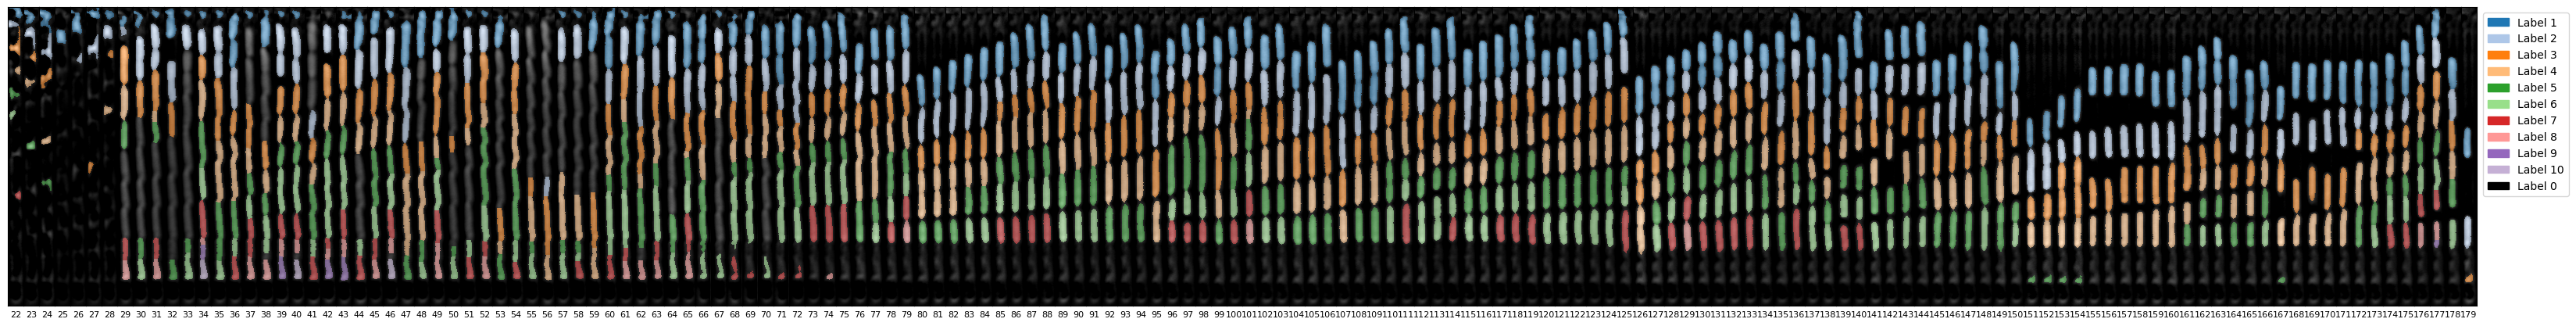

In [7]:
#previous troubhleshooting setup
phase_channel = '0'
fluor_channel = '1'
for folder, fov_dict in seg_FOV_dict.items():
    for fov_id in fov_dict.keys():
        ana_peak_ids = fov_dict[fov_id]
        for peak_id in ana_peak_ids:
            current_end_frame = end_frame
            path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            if current_end_frame is None:
                current_end_frame = get_tiff_frame_count(path_to_phase_stack)
            path_to_fluor_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_channel}.tif'
            output_path = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/outputs'
            labeled_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            segment_chnl_stack(
                   path_to_phase_stack,
                   output_path,
                   OTSU_threshold=1.5,
                   first_opening=2,
                   distance_threshold=2.1,
                   second_opening_size=2,
                   min_cell_area=90,
				   max_cell_area=1000,
                   small_merge_area_threshold=200,
                   seg_params=seg_params,
                   first_opening_morph=None,
                   second_opening_morph=None,
                   )
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=22, end=180, alpha=0.5)
            # plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=34, end=35, alpha=0.5)

### Here is wher you can test paramters you've tested to determine what range of time points they might cover 

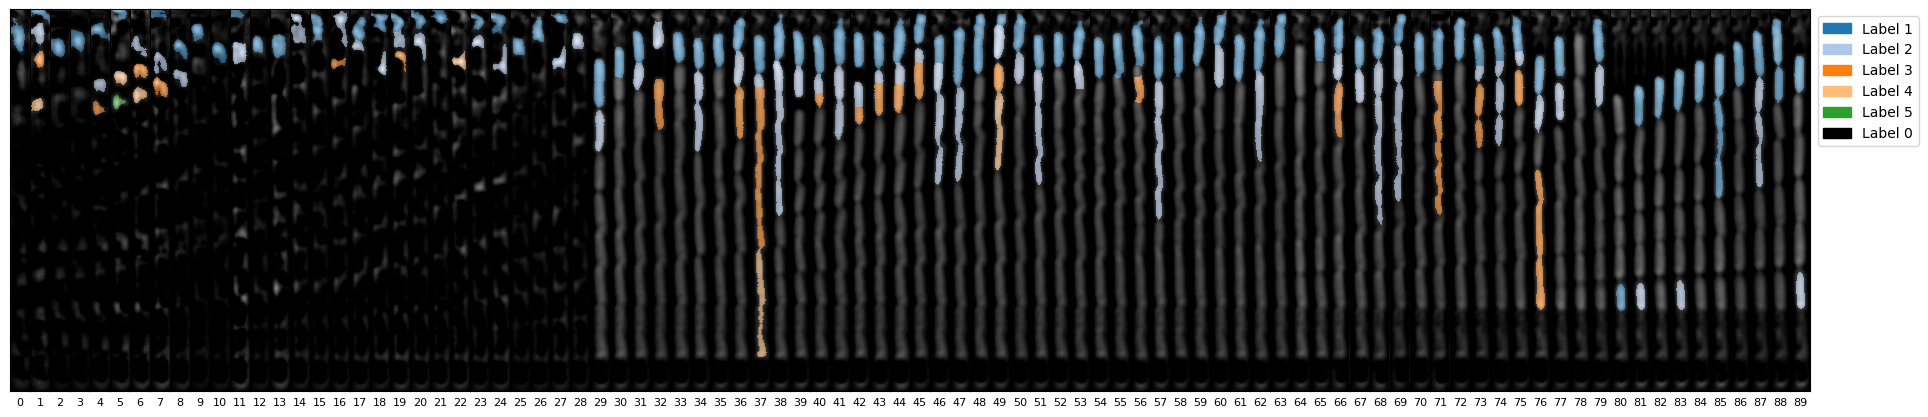

In [8]:
#previous troubhleshooting setup
phase_channel = '0'
fluor_channel = '1'
for folder, fov_dict in seg_FOV_dict.items():
    for fov_id in fov_dict.keys():
        ana_peak_ids = fov_dict[fov_id]
        for peak_id in ana_peak_ids:
            current_end_frame = end_frame
            path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            if current_end_frame is None:
                current_end_frame = get_tiff_frame_count(path_to_phase_stack)
            path_to_fluor_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_channel}.tif'
            output_path = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/outputs'
            labeled_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            mm3seg.segment_chnl_stack(
                   path_to_phase_stack,
                   output_path,
                   OTSU_threshold=1.5,
                   first_opening=2,
                   distance_threshold=2.1,
                   second_opening_size=2,
                   min_cell_area=90,
				   max_cell_area=1000,
                   small_merge_area_threshold=50,
				   first_opening_morph=None,
				   second_opening_morph=None)
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=0, end=90, alpha=0.5)
            # plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=34, end=35, alpha=0.5)

## Here is where the troubleshooting begin. First pick a time frame you want to look at 
## and update the info appropriately 
## peak_id is the same as trench id 

In [9]:
fov ='005'
peak_id ='2344'
frame=62
path_to_phase_stack = f'{base_dir}/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
image = tifffile.imread(path_to_phase_stack)[frame]
plt.figure()
plt.imshow(image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/DUMM_giTG69_Glucose_013025/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_007_region_2344_c_0.tif'

# Otsu threshold
Test different otsu_thresh values. The mask will be dependent on the otsu threshold, individual cell labeling will depend on everything else so it is okay if cells are somewhat joined together

Main goal is to make sure we see the correct number of cells

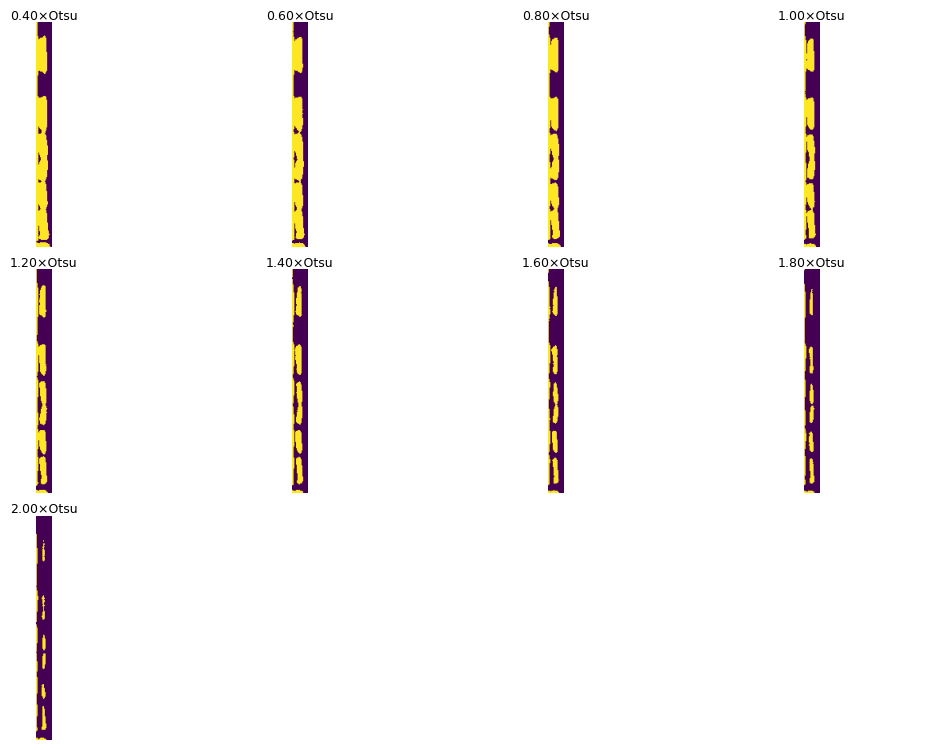

In [ ]:
otsu_min = 0.4
otsu_max = 2.0
step = 0.20
otsu_values = np.round(np.arange(otsu_min, otsu_max + 1e-9, step), 2)

scale = np.median(image) / np.mean(image)  # kept from your code (unused below)
img = image.astype(np.float32)
img = (img - np.percentile(img, 1)) / (np.percentile(img, 99) - np.percentile(img, 1))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    thresh = filters.threshold_otsu(img)

# --- plot side-by-side (auto-wrap rows) ---
n = len(otsu_values)
ncols = min(4, n)                 
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(2.6*ncols, 2.6*nrows))
axes = np.atleast_1d(axes).ravel()

for i, otsu_mult in enumerate(otsu_values):
    thresholded = img > (otsu_mult * thresh)
    axes[i].imshow(thresholded)
    axes[i].set_title(f"{otsu_mult:.2f}×Otsu", fontsize=9, pad=2)
    axes[i].axis("off")

# hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.01, wspace=0.02, hspace=0.10)
plt.show()

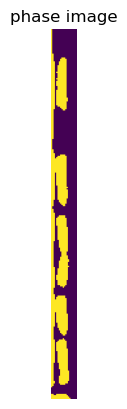

In [ ]:
otsu_thresh = 1.2
image = tifffile.imread(path_to_phase_stack)[frame]

# normalization if using 
scale = np.median(image) / np.mean(image)
image = image.astype(np.float32)
image = (image - np.percentile(image, 1)) / (
    np.percentile(image, 99) - np.percentile(image, 1)
)

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        thresh = filters.threshold_otsu(image)
    thresholded = image > otsu_thresh * thresh
    
except Exception as e:
        print(f"Error in initial processing: {e}")

plt.figure()
plt.imshow(thresholded)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


# First opening
Here wee mess with the first opening. Ultimately want to maintain centroids here so don't worry about how small cells are. 


You may need to change the morphological opening shape for either diagnol or spherical 

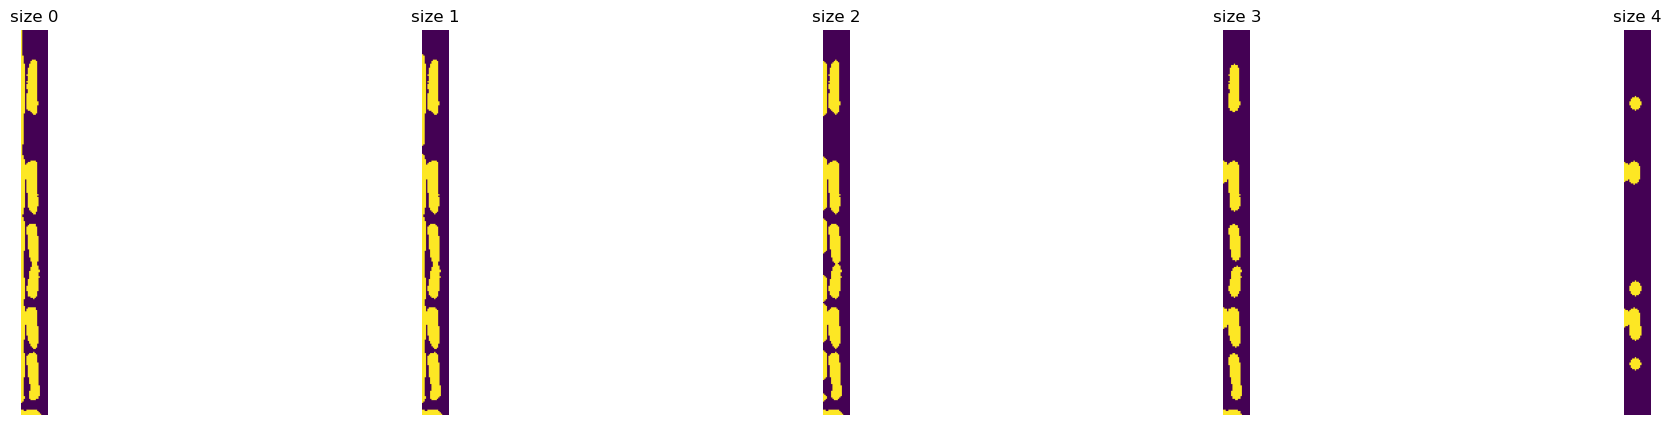

In [ ]:
min_size = 0          
max_size = 4      
first_opening_morph = 0 

sizes = list(range(min_size, max_size + 1))
fig, axes = plt.subplots(1, len(sizes), figsize=(5*len(sizes), 5))


for ax, first_opening in zip(axes, sizes):
    if first_opening_morph == 0:
    
        morph_test = morphology.binary_opening(thresholded, morphology.disk(first_opening)) 
    
    elif first_opening_morph == 1:           
        diagonal_footprint = np.zeros((first_opening, first_opening))
        np.fill_diagonal(diagonal_footprint, 1)
        morph_test = morphology.binary_opening(thresholded, diagonal_footprint)

    ax.imshow(morph_test)
    ax.set_title(f"size {first_opening}")
    ax.axis("off")
plt.tight_layout
plt.show()

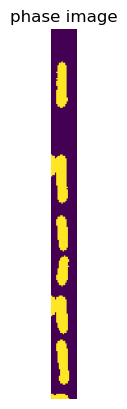

In [ ]:
# change but is int not double 
first_opening = 3
first_opening_morph = 0   

if first_opening_morph == 0:

    morph = morphology.binary_opening(thresholded, morphology.disk(first_opening))

elif first_opening_morph == 1:
    diagonal_footprint = np.zeros((first_opening, first_opening))
    np.fill_diagonal(diagonal_footprint, 1)
    morph = morphology.binary_opening(thresholded, diagonal_footprint)

plt.figure()
plt.imshow(morph)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# Distance threshold 
Again goal is to retain the number of objects here and make sure cells are separate 

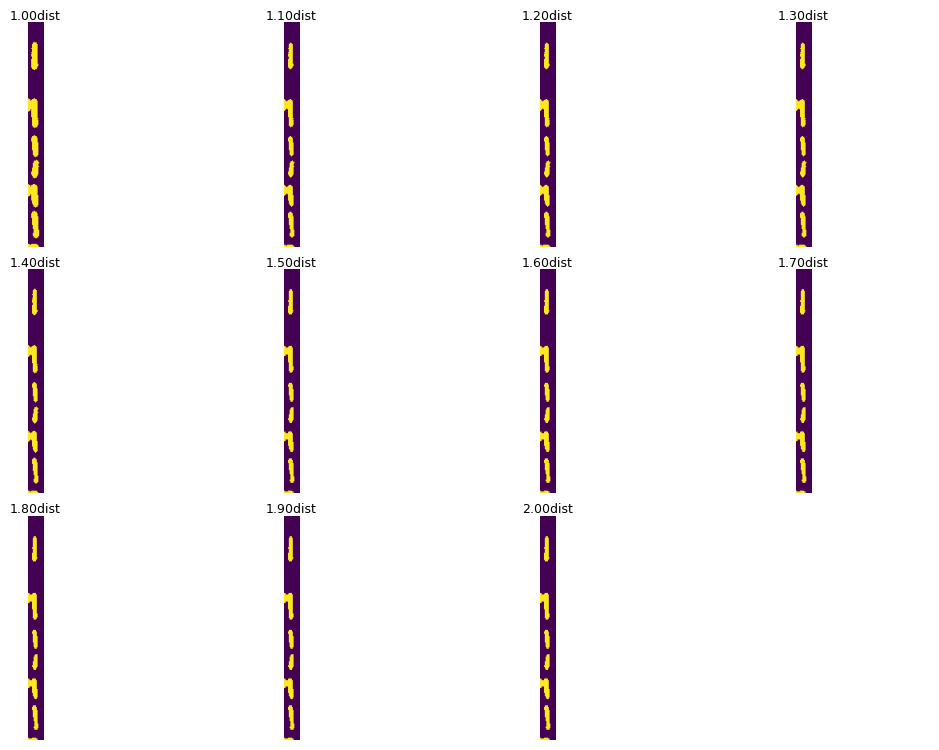

In [ ]:
dist_min = 1.0
dist_max = 2.0
step = 0.1
dist_values = np.round(np.arange(dist_min, dist_max + 1e-9, step), 2)
distance = ndi.distance_transform_edt(morph)
# --- plot side-by-side (auto-wrap rows) ---
n = len(dist_values)
ncols = min(4, n)                 
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(2.6*ncols, 2.6*nrows))
axes = np.atleast_1d(axes).ravel()

for i, dist_mult in enumerate(dist_values):
    distance_thresh_test = distance >= dist_mult
    axes[i].imshow(distance_thresh_test)
    axes[i].set_title(f"{dist_mult:.2f}dist", fontsize=9, pad=2)
    axes[i].axis("off")

# hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.01, wspace=0.02, hspace=0.10)
plt.show()

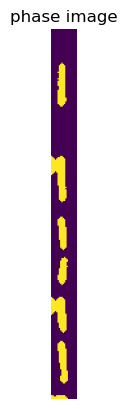

In [ ]:
distance_threshold = 1.2
distance = ndi.distance_transform_edt(morph)
distance_thresh = distance >= distance_threshold
plt.figure()
plt.imshow(distance_thresh)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()



# Second opening 
Further segment cells, can opt to not use it by setting the value to 0

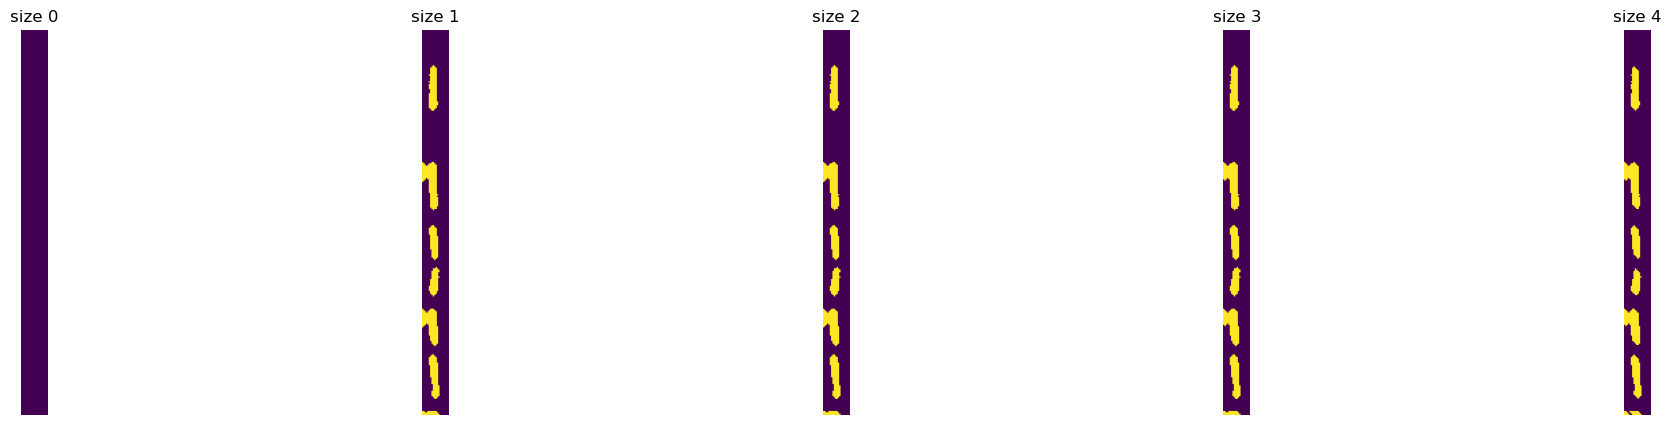

In [ ]:
min_size = 0          
max_size = 4          
second_opening_morph = 1


sizes = list(range(min_size, max_size + 1))
fig, axes = plt.subplots(1, len(sizes), figsize=(5*len(sizes), 5))

for ax, second_opening_size in zip(axes, sizes):
    if second_opening_morph == 0:

        distance_opened_test = morphology.binary_opening(distance_thresh, morphology.disk(second_opening_size))

    elif second_opening_morph == 1:
        diagonal_footprint_two = np.zeros((second_opening_size, second_opening_size), dtype=bool)
        np.fill_diagonal(diagonal_footprint_two, True)
        distance_opened_test = morphology.binary_opening(distance_thresh, diagonal_footprint_two)

    ax.imshow(distance_opened_test)
    ax.set_title(f"size {second_opening_size}")
    ax.axis("off")
plt.tight_layout
plt.show()


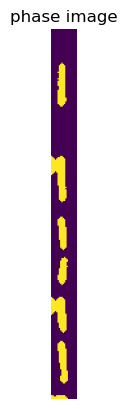

In [ ]:
second_opening_size = 0
second_opening_morph = 0

if second_opening_morph == 0:
    distance_opened = morphology.binary_opening(distance_thresh, morphology.disk(second_opening_size))

elif second_opening_morph == 1:
    diagonal_footprint_two = np.zeros((second_opening_size, second_opening_size), dtype=bool)
    np.fill_diagonal(diagonal_footprint_two, True)
    distance_opened = morphology.binary_opening(distance_thresh, diagonal_footprint_two)

plt.figure()
plt.imshow(distance_opened)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# labeling and markers and Watershed begins here
Apply labels to cells that have been segmented. Labeled will be used for watershed I believe markers will be used only to create a mask 

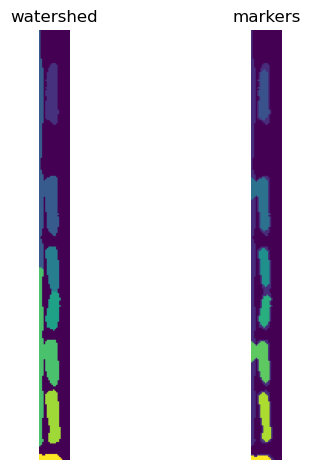

In [ ]:
labeled, num_labels = morphology.label(distance_opened, connectivity=1, return_num=True)
markers = morphology.label(labeled, connectivity=1)
markers = markers.astype(np.int32)

thresholded_watershed = thresholded
image_float = image.astype(np.float64)
try:
     markers[thresholded_watershed == 0] = -1
     with warnings.catch_warnings():
          warnings.simplefilter("ignore")
          labeled_image = segmentation.random_walker(-1 * image_float, markers)
     labeled_image[labeled_image == -1] = 0
except Exception as e:
        print(f"Error in watershed segmentation: {e}")

plt.figure()  # Change the figure size as needed

plt.subplot(1, 2, 1)
plt.imshow(labeled_image)
plt.title('watershed')
plt.axis('off')  # Hide axis labels
plt.subplot(1, 2, 2)
plt.imshow(markers)
plt.title('markers')
plt.axis('off')  # Hide axis labels
plt.tight_layout()  # Adjust layout to make it nicer
plt.draw()



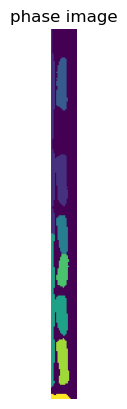

In [ ]:
small_merge_area_threshold = 200
regions = measure.regionprops(labeled_image)
if regions:
        bboxes = np.array([region.bbox for region in regions])
        areas = np.array([region.area for region in regions])
        graph = nx.Graph()

        for i, bbox1 in enumerate(bboxes):
            for j, bbox2 in enumerate(bboxes):
                if i != j and overlap(bbox1, bbox2) and areas[i] < small_merge_area_threshold and areas[j] < small_merge_area_threshold:
                    graph.add_edge(regions[i].label, regions[j].label)

        for component in nx.connected_components(graph):
            if len(component) > 1:
                merged_mask = np.isin(labeled_image, list(component))
                new_label = np.max(labeled_image) + 1
                labeled_image[merged_mask] = new_label
                for label in component:
                    labeled_image[labeled_image == label] = 0

        labeled_image, num_labels_new = morphology.label(labeled_image, connectivity=1, return_num=True)

plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


### Shape Filtering (axis Ratio)

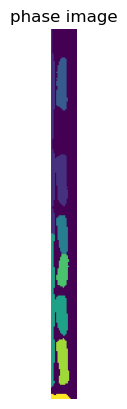

In [ ]:
min_axis_ratio=0.04 # 0.04 is the default value
filtered_labeled_image = np.zeros_like(labeled_image)
regions = measure.regionprops(labeled_image)

for region in regions:
    if region.axis_major_length > 0:
        axis_ratio = region.axis_minor_length / region.axis_major_length
        if (axis_ratio > min_axis_ratio) | (region.axis_minor_length > 3.5):
            filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label

labeled_image = filtered_labeled_image

plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

### size filtering

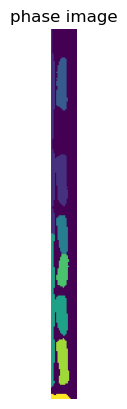

In [ ]:
min_cell_area=50
max_cell_area=750
if min_cell_area is not None or max_cell_area is not None:
  filtered_labeled_image = np.zeros_like(labeled_image)
  regions = measure.regionprops(labeled_image)
  for region in regions:
    area = region.area
    if (min_cell_area is None or area >= min_cell_area) and (max_cell_area is None or area <= max_cell_area):
       filtered_labeled_image[region.coords[:, 0], region.coords[:, 1]] = region.label

new_labeled_image = filtered_labeled_image
plt.figure()
plt.imshow(new_labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide a
plt.draw()